# PoC Evaluate — Multi-Pocket Results

Loads `eval_results.pt` from each of the 5 pockets produced by:
```bash
N_POCKETS=5 TRAIN_N=20 bash scripts/09_poc_compare_samples.sh crops
for i in 0000 0001 0002 0003 0004; do
    COMPARE_DIR="exps/poc_xray/compare_20/pocket_${i}" bash scripts/10_poc_evaluate.sh vina_score
done
```

| Section | Contents |
|---|---|
| 1. Config | Pocket dirs, conditions, colors |
| 2. Per-pocket tables | Summary table for each pocket |
| 3. Aggregated bar charts | Mean ± std across pockets per condition |
| 4. Per-metric box plots | Distribution across pockets |

In [1]:
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})
print('Imports OK')

Imports OK


## 1. Config

In [2]:
COMPARE_ROOT = Path('../voxbind/exps/poc_xray/compare_20')
N_POCKETS    = 5
POCKET_DIRS  = [COMPARE_ROOT / f'pocket_{i:04d}' for i in range(N_POCKETS)]

CONDITIONS  = ['baseline', 'finetuned', 'xray_cond']
COND_COLOR  = {
    'baseline':  'cornflowerblue',
    'finetuned': 'gold',
    'xray_cond': 'tomato',
}

# Metrics to display and their "better" direction
METRICS = [
    ('QED mean',        '↑'),
    ('SA mean',         '↓'),
    ('LogP mean',       None),
    ('Lipinski mean',   '↑'),
    ('Diversity',       '↑'),
    ('Vina score mean', '↓'),
    ('Vina min mean',   '↓'),
]

## 2. Load eval_results.pt from each pocket

In [3]:
pocket_data = []   # list of dicts: {pocket_idx, path, summaries, conditions}

for idx, pocket_dir in enumerate(POCKET_DIRS):
    pt_path = pocket_dir / 'eval_results.pt'
    if not pt_path.exists():
        print(f'  pocket_{idx:04d}  MISSING  ({pt_path})')
        continue
    data = torch.load(str(pt_path), weights_only=False)
    pocket_data.append({
        'idx':        idx,
        'path':       pocket_dir,
        'summaries':  data['summaries'],
        'conditions': data['conditions'],
    })
    present = list(data['summaries'].keys())
    n_mols  = {c: data['summaries'][c].get('n', 0) for c in present}
    print(f'  pocket_{idx:04d}  loaded  conditions={present}  n_mols={n_mols}')

print(f'\n{len(pocket_data)} / {N_POCKETS} pockets loaded.')

  pocket_0000  loaded  conditions=['baseline', 'finetuned', 'xray_cond']  n_mols={'baseline': 9, 'finetuned': 5, 'xray_cond': 10}
  pocket_0001  loaded  conditions=['baseline', 'finetuned', 'xray_cond']  n_mols={'baseline': 10, 'finetuned': 2, 'xray_cond': 10}
  pocket_0002  loaded  conditions=['baseline', 'finetuned', 'xray_cond']  n_mols={'baseline': 10, 'finetuned': 2, 'xray_cond': 10}
  pocket_0003  MISSING  (../voxbind/exps/poc_xray/compare_20/pocket_0003/eval_results.pt)
  pocket_0004  MISSING  (../voxbind/exps/poc_xray/compare_20/pocket_0004/eval_results.pt)

3 / 5 pockets loaded.


## 3. Per-pocket summary tables

In [4]:
def print_summary_table(summaries, title=''):
    conditions = [c for c in CONDITIONS if c in summaries]
    all_keys   = sorted({k for s in summaries.values() for k in s if k != 'n'})

    col_w  = 18
    header = f'{"Metric":<26}' + ''.join(f'{c:>{col_w}}' for c in conditions)
    sep    = '-' * len(header)

    if title:
        print(f'\n{title}')
    print(sep)
    print(header)
    print(sep)
    print(f'{"n (molecules)":<26}' +
          ''.join(f'{summaries[c].get("n", 0):>{col_w}d}' for c in conditions))
    for m in all_keys:
        vals = ''.join(
            f'{summaries[c].get(m, float("nan")):>{col_w}.3f}'
            for c in conditions
        )
        print(f'{m:<26}{vals}')
    print(sep)


for pd in pocket_data:
    print_summary_table(
        pd['summaries'],
        title=f"=== pocket_{pd['idx']:04d}  ({pd['path'].name}) ==="
    )


=== pocket_0000  (pocket_0000) ===
--------------------------------------------------------------------------------
Metric                              baseline         finetuned         xray_cond
--------------------------------------------------------------------------------
n (molecules)                              9                 5                10
Diversity                              0.889             0.973             0.880
Lipinski mean                          5.000             5.000             5.000
Lipinski median                        5.000             5.000             5.000
LogP mean                              1.525             0.717             2.026
LogP median                            1.636             0.636             2.473
QED mean                               0.684             0.361             0.486
QED median                             0.700             0.360             0.529
SA mean                                0.683             0.564           

## 4. Aggregated bar charts (mean ± std across pockets)

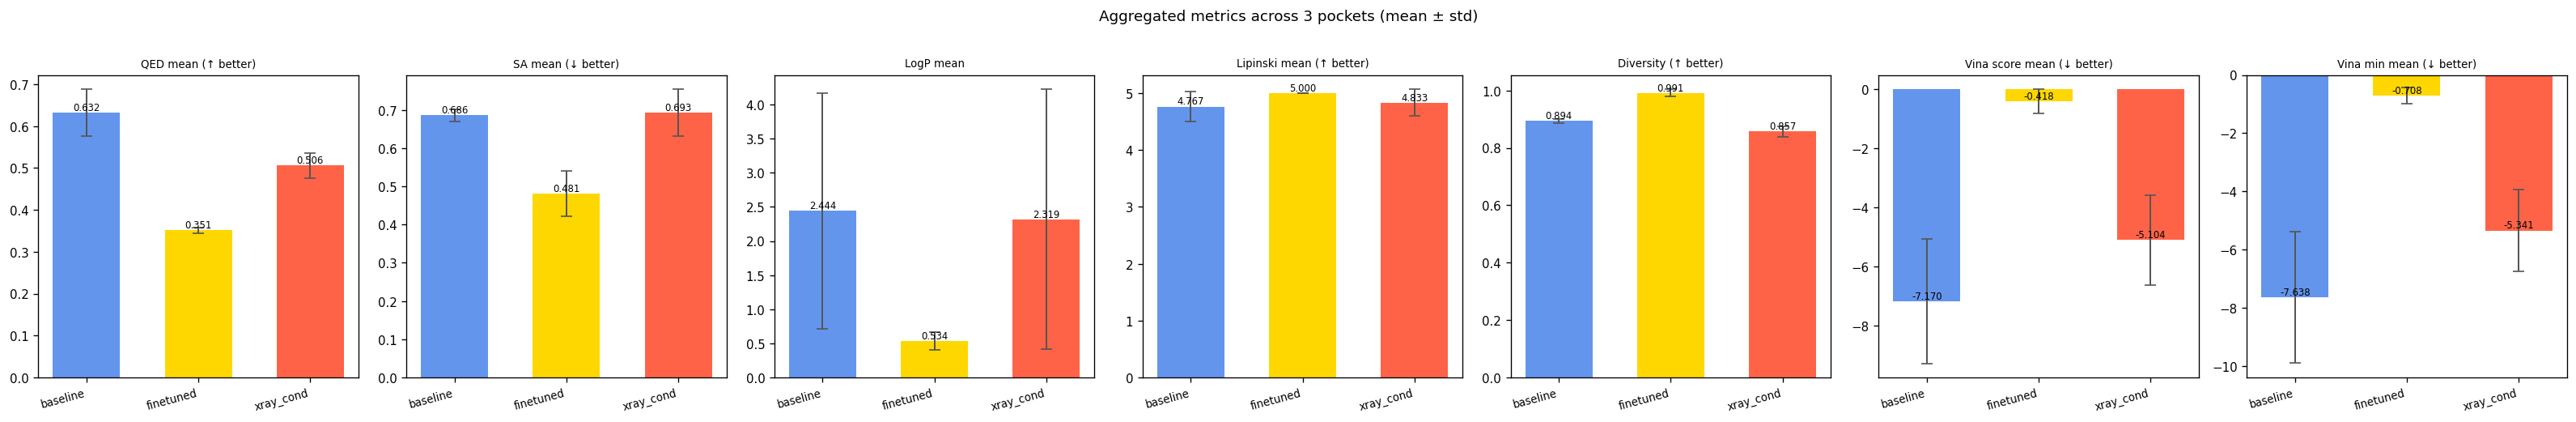

In [5]:
# Collect per-metric values across pockets for each condition
# agg[condition][metric] = list of values (one per pocket)
agg = {c: {m: [] for m, _ in METRICS} for c in CONDITIONS}

for pd in pocket_data:
    for cond in CONDITIONS:
        s = pd['summaries'].get(cond, {})
        for metric, _ in METRICS:
            v = s.get(metric, float('nan'))
            agg[cond][metric].append(v)

# Filter to conditions actually present in any pocket
present_conds = [c for c in CONDITIONS
                 if any(c in pd['summaries'] for pd in pocket_data)]

# Filter to metrics actually present
present_metrics = [
    (m, arrow) for m, arrow in METRICS
    if any(
        not math.isnan(v)
        for c in present_conds
        for v in agg[c][m]
    )
]

n_metrics = len(present_metrics)
fig, axes = plt.subplots(1, n_metrics, figsize=(3.8 * n_metrics, 4.2))
if n_metrics == 1:
    axes = [axes]

x = np.arange(len(present_conds))
bar_w = 0.6

for ax, (metric, arrow) in zip(axes, present_metrics):
    means = [np.nanmean(agg[c][metric]) for c in present_conds]
    stds  = [np.nanstd(agg[c][metric])  for c in present_conds]
    colors = [COND_COLOR.get(c, 'steelblue') for c in present_conds]

    bars = ax.bar(x, means, bar_w, yerr=stds, capsize=4,
                  color=colors, edgecolor='none',
                  error_kw=dict(elinewidth=1.2, ecolor='#555'))

    for bar, m in zip(bars, means):
        if not math.isnan(m):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{m:.3f}', ha='center', va='bottom', fontsize=7)

    title = f'{metric}' + (f' ({arrow} better)' if arrow else '')
    ax.set_title(title, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(present_conds, rotation=15, ha='right', fontsize=8)

fig.suptitle(
    f'Aggregated metrics across {len(pocket_data)} pockets (mean ± std)',
    fontsize=11, y=1.02
)
fig.tight_layout()
plt.show()

## 5. Per-metric box plots (distribution across pockets)

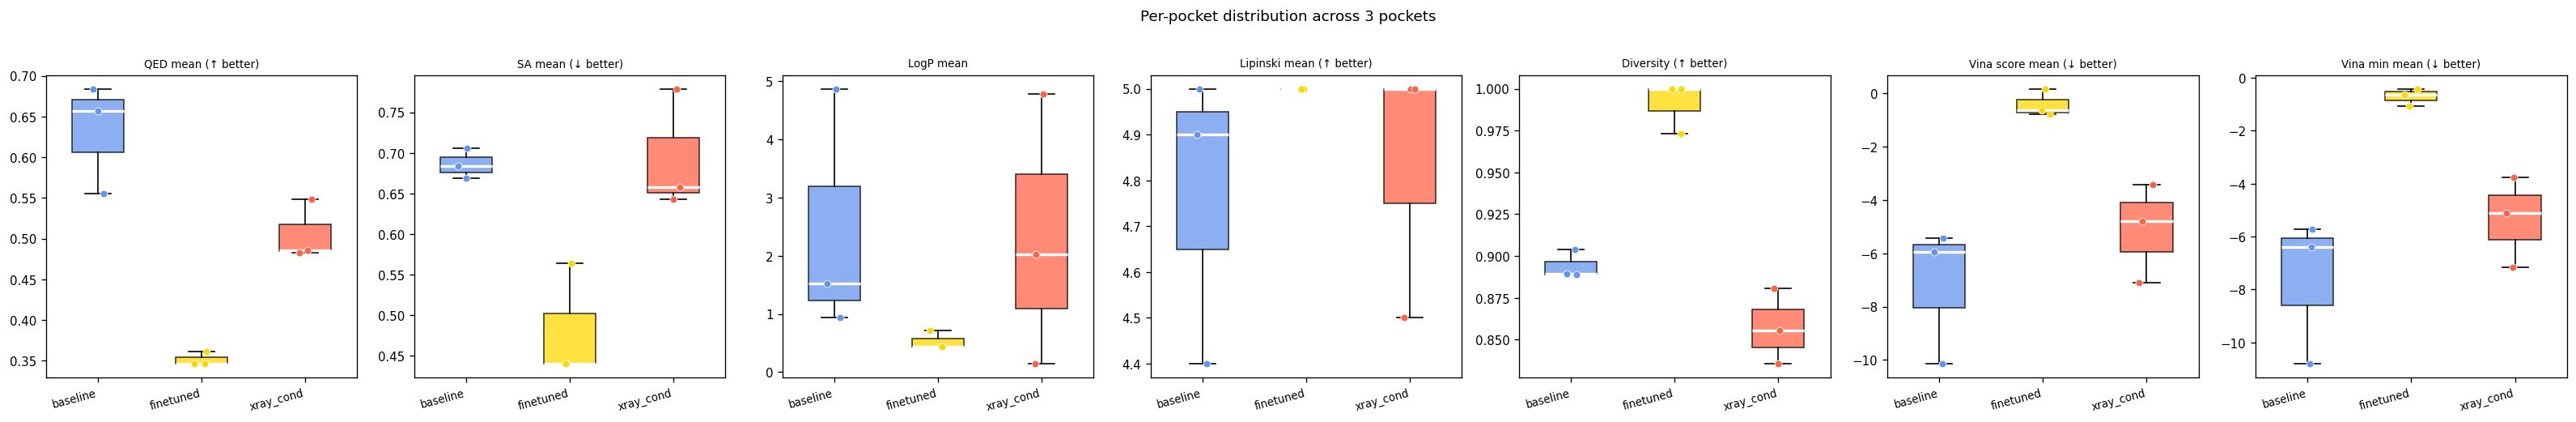

In [6]:
n_metrics = len(present_metrics)
fig, axes = plt.subplots(1, n_metrics, figsize=(3.8 * n_metrics, 4.2))
if n_metrics == 1:
    axes = [axes]

for ax, (metric, arrow) in zip(axes, present_metrics):
    data_per_cond = [
        [v for v in agg[c][metric] if not math.isnan(v)]
        for c in present_conds
    ]
    colors = [COND_COLOR.get(c, 'steelblue') for c in present_conds]

    bp = ax.boxplot(data_per_cond, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # Overlay individual pocket points
    for i, (vals, color) in enumerate(zip(data_per_cond, colors), start=1):
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=color, edgecolors='white', s=28, zorder=3, linewidths=0.5)

    ax.set_xticks(range(1, len(present_conds) + 1))
    ax.set_xticklabels(present_conds, rotation=15, ha='right', fontsize=8)
    title = f'{metric}' + (f' ({arrow} better)' if arrow else '')
    ax.set_title(title, fontsize=8)

fig.suptitle(
    f'Per-pocket distribution across {len(pocket_data)} pockets',
    fontsize=11, y=1.02
)
fig.tight_layout()
plt.show()

## 6. Combined aggregated table (mean ± std across pockets)

In [7]:
col_w  = 22
header = f'{"Metric":<26}' + ''.join(f'{c:>{col_w}}' for c in present_conds)
sep    = '-' * len(header)

print(f'Aggregated over {len(pocket_data)} pockets  (mean ± std)')
print(sep)
print(header)
print(sep)

for metric, arrow in present_metrics:
    row = f'{metric:<26}'
    for c in present_conds:
        vals = [v for v in agg[c][metric] if not math.isnan(v)]
        if vals:
            cell = f'{np.mean(vals):.3f} ± {np.std(vals):.3f}'
        else:
            cell = 'N/A'
        row += f'{cell:>{col_w}}'
    print(row)

print(sep)

Aggregated over 3 pockets  (mean ± std)
--------------------------------------------------------------------------------------------
Metric                                  baseline             finetuned             xray_cond
--------------------------------------------------------------------------------------------
QED mean                           0.632 ± 0.055         0.351 ± 0.007         0.506 ± 0.030
SA mean                            0.686 ± 0.015         0.481 ± 0.058         0.693 ± 0.061
LogP mean                          2.444 ± 1.730         0.534 ± 0.129         2.319 ± 1.905
Lipinski mean                      4.767 ± 0.262         5.000 ± 0.000         4.833 ± 0.236
Diversity                          0.894 ± 0.007         0.991 ± 0.013         0.857 ± 0.018
Vina score mean                   -7.170 ± 2.107        -0.418 ± 0.420        -5.104 ± 1.520
Vina min mean                     -7.638 ± 2.253        -0.708 ± 0.268        -5.341 ± 1.401
------------------------------